# Week 3 — Task 1: Trained Machine Learning Models

**Dataset:** RIT Opportunity Wise Dataset (8,558 rows, 29 columns)  
**Target Variable:** `Is_Dropped` — 1 if the student dropped out or withdrew, 0 otherwise  
**Models Used:** Logistic Regression (baseline) + Random Forest Classifier (main model)

---

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,precision_score,recall_score,f1_score,roc_curve,auc
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
print("libraries imported successfully.")

libraries imported successfully.


## Step 2: Load Dataset

In [2]:
df = pd.read_csv(r"/content/RIT_Dataset_Week2_Cleaned.csv")
print("Shape:", df.shape)
df.head(3)
print(df.columns)

Shape: (8558, 29)
Index(['Learner SignUp DateTime', 'Opportunity Id', 'Opportunity Name',
       'Opportunity Category', 'Opportunity End Date', 'First Name',
       'Date of Birth', 'Gender', 'Country', 'Institution Name',
       'Current/Intended Major', 'Entry created at', 'Status Description',
       'Status Code', 'Apply Date', 'Opportunity Start Date',
       'Start_Date_Missing', 'Age', 'Age Group', 'Signup Year', 'Signup Month',
       'Cohort_Missing', 'Signup Cohort', 'Days to Apply',
       'Apply to Start Gap', 'Opportunity Duration (Days)', 'Engagement Stage',
       'Is_Completed', 'Is_Dropped'],
      dtype='object')


## Step 3: Define Target & Drop Leakage Columns

The target is `Is_Dropped`. Columns dropped here fall into four categories:
- **Data leakage** — derived from the target itself (`Status Description`, `Status Code`, `Engagement Stage`, `Is_Completed`)
- **Identifiers** — names, IDs, and institution details that carry no predictive signal
- **Raw date columns** — already replaced by engineered features (`Days to Apply`, `Apply to Start Gap`)
- **Low-signal flags** — `Cohort_Missing`, `Start_Date_Missing`, `Opportunity Duration (Days)`

In [3]:
drop_cols = [
    # target + leakage
    'Is_Dropped', 'Is_Completed', 'Engagement Stage',
    'Status Description', 'Status Code',
    # identifiers
    'First Name', 'Opportunity Id', 'Opportunity Name',
    'Institution Name', 'Current/Intended Major',
    # raw dates (replaced by engineered features)
    'Learner SignUp DateTime', 'Apply Date',
    'Opportunity Start Date', 'Opportunity End Date', 'Date of Birth',
    'Entry created at',
    # low-signal / flag columns
    'Signup Cohort', 'Cohort_Missing', 'Start_Date_Missing',
    'Opportunity Duration (Days)',
]

y = df['Is_Dropped']
X = df.drop(columns=drop_cols)

print("Target distribution:")
print(y.value_counts())
print("\nFeatures used for training:")
print(X.columns.tolist())

Target distribution:
Is_Dropped
0    7855
1     703
Name: count, dtype: int64

Features used for training:
['Opportunity Category', 'Gender', 'Country', 'Age', 'Age Group', 'Signup Year', 'Signup Month', 'Days to Apply', 'Apply to Start Gap']


## Step 4: Label Encoding + Null Handling

ML models require numeric inputs. All categorical text columns (`Gender`, `Country`, `Opportunity Category`, `Age Group`) are converted using `LabelEncoder`, which assigns each unique string a unique integer. Boolean columns are cast to 0/1. Remaining nulls — mainly in `Days to Apply` and `Apply to Start Gap` due to missing date records — are filled with the column median, which preserves the distribution without introducing outliers.

In [4]:
x = X.copy()

# encode categorical text columns
for col in x.select_dtypes(include='object').columns:
    x[col] = LabelEncoder().fit_transform(x[col].astype(str))

# encode boolean columns
for col in x.select_dtypes(include='bool').columns:
    x[col] = x[col].astype(int)

# fill remaining nulls with median
x = x.fillna(x.median())

print("Encoded feature matrix shape:", x.shape)
print(x.dtypes)

Encoded feature matrix shape: (8558, 9)
Opportunity Category      int64
Gender                    int64
Country                   int64
Age                       int64
Age Group                 int64
Signup Year             float64
Signup Month            float64
Days to Apply           float64
Apply to Start Gap      float64
dtype: object


## Step 5: Train-Test Split

Data is split 80/20 — 80% for training, 20% held out for testing. `random_state=42` ensures the split is reproducible and identical for both models, making the accuracy comparison fair.

In [5]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print("Training set:", x_train.shape)
print("Test set    :", x_test.shape)
print("\nClass balance in training set:")
print(y_train.value_counts())

Training set: (6846, 9)
Test set    : (1712, 9)

Class balance in training set:
Is_Dropped
0    6297
1     549
Name: count, dtype: int64


## Model 1: Logistic Regression (Baseline)

**Algorithm:** Logistic Regression draws a linear decision boundary between the two classes based on a weighted combination of input features. It outputs a dropout probability via the sigmoid function and classifies a student as "Dropped" if that probability exceeds 0.5.

**Key Parameters:**
- `max_iter=1000` — allows the solver to fully converge given the imbalanced data
- `class_weight='balanced'` — automatically adjusts class weights inversely proportional to frequency; without this, the model ignores the minority Dropped class entirely (only ~8% of data)
- `random_state=42` — reproducibility

**Why use it:** Logistic Regression is an interpretable baseline. It tells us the minimum acceptable performance that a more complex model must beat to justify its extra complexity.

In [6]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(x_train, y_train)

lr_pred = lr.predict(x_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", round(lr_accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Not Dropped', 'Dropped']))

Logistic Regression Accuracy: 63.49 %

Classification Report:
              precision    recall  f1-score   support

 Not Dropped       0.96      0.62      0.76      1558
     Dropped       0.17      0.77      0.27       154

    accuracy                           0.63      1712
   macro avg       0.57      0.69      0.52      1712
weighted avg       0.89      0.63      0.71      1712



## Model 2: Random Forest Classifier (Main Model)

**Algorithm:** Random Forest is an ensemble of 100 decision trees. Each tree is trained on a random bootstrap sample of the data and evaluates only a random subset of features at each split. At prediction time, all 100 trees vote and the majority class wins. This makes it robust to overfitting and capable of capturing non-linear interactions between features.

**Key Parameters:**
- `n_estimators=100` — 100 trees; enough for stable and accurate predictions
- `class_weight='balanced'` — same minority-class correction as Logistic Regression for fair comparison
- `random_state=42` — reproducibility

**Why it is expected to outperform Logistic Regression:** Dropout likelihood is influenced by combinations of factors — e.g., young students applying to internships with long gaps before start — that a single linear boundary cannot capture. Random Forest models these interactions naturally.

In [7]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Not Dropped', 'Dropped']))

Random Forest Accuracy: 87.73 %

Classification Report:
              precision    recall  f1-score   support

 Not Dropped       0.95      0.91      0.93      1558
     Dropped       0.37      0.50      0.42       154

    accuracy                           0.88      1712
   macro avg       0.66      0.71      0.68      1712
weighted avg       0.90      0.88      0.89      1712



## Model Comparison

                 Model  Accuracy (%)
0  Logistic Regression         63.49
1        Random Forest         87.73


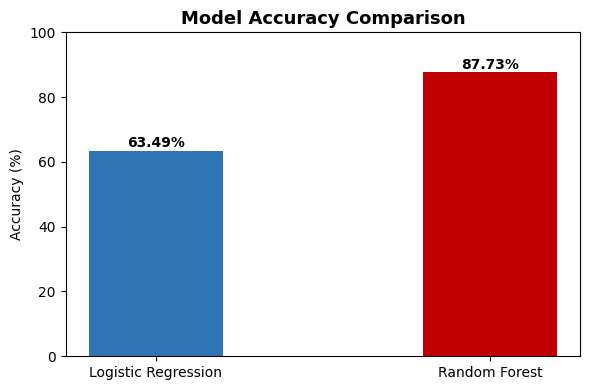

Random Forest selected as the primary model for Tasks 2 and 3.


In [8]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy (%)': [
        round(lr_accuracy * 100, 2),
        round(rf_accuracy * 100, 2)
    ]
})
print(comparison)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(comparison['Model'], comparison['Accuracy (%)'],
              color=['#2E75B6', '#C00000'], width=0.4)
ax.set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print("Random Forest selected as the primary model for Tasks 2 and 3.")

# TASK 2: PREDICTED PROBABILITIES

## STEP 1: Generate Predicted Probabilities on Test Set

In [9]:
rf_proba = rf.predict_proba(x_test)
prob_not_dropped = rf_proba[:, 0]
prob_dropped = rf_proba[:, 1]

print("-" * 70)
print("TASK 2: PREDICTED PROBABILITIES")
print("-" * 70)
print(f"\nProbability Statistics (Test Set - {len(x_test)} students):")
print(f"  Participation Strength (1 - Dropout Risk):")
print(f"    Mean:   {prob_not_dropped.mean():.4f}")
print(f"    Min:    {prob_not_dropped.min():.4f}")
print(f"    Max:    {prob_not_dropped.max():.4f}")
print(f"    Median: {np.median(prob_not_dropped):.4f}")
print(f"\n  Dropout Risk Probability:")
print(f"    Mean:   {prob_dropped.mean():.4f}")
print(f"    Min:    {prob_dropped.min():.4f}")
print(f"    Max:    {prob_dropped.max():.4f}")
print(f"    Median: {np.median(prob_dropped):.4f}")

----------------------------------------------------------------------
TASK 2: PREDICTED PROBABILITIES
----------------------------------------------------------------------

Probability Statistics (Test Set - 1712 students):
  Participation Strength (1 - Dropout Risk):
    Mean:   0.8706
    Min:    0.0000
    Max:    1.0000
    Median: 1.0000

  Dropout Risk Probability:
    Mean:   0.1294
    Min:    0.0000
    Max:    1.0000
    Median: 0.0000


## STEP 2: Create Probabilities DataFrame with Opportunity Information

In [10]:
x_test_original = X.iloc[x_test.index].copy()
y_test_original = y.iloc[x_test.index].copy()

prob_df = pd.DataFrame({
    'Student_ID': range(len(x_test)),
    'Opportunity_Category': x_test_original['Opportunity Category'].values,
    'Actual_Is_Dropped': y_test_original.values,
    'Predicted_Dropout_Risk': np.round(prob_dropped, 4),
    'Predicted_Participation_Strength': np.round(prob_not_dropped, 4),
})

prob_df['Participation_Category'] = pd.cut(
    prob_df['Predicted_Participation_Strength'],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Very Low (0-0.3)', 'Low (0.3-0.5)', 'High (0.5-0.7)', 'Very High (0.7-1.0)']
)

print("\n" + "-" * 70)
print("PARTICIPATION STRENGTH BY CATEGORY")
print("-" * 70)
print("\nTop 20 Students with Highest Participation Strength:")
print(prob_df.nlargest(20, 'Predicted_Participation_Strength')[
    ['Opportunity_Category', 'Predicted_Participation_Strength', 'Actual_Is_Dropped']
].to_string(index=False))


----------------------------------------------------------------------
PARTICIPATION STRENGTH BY CATEGORY
----------------------------------------------------------------------

Top 20 Students with Highest Participation Strength:
Opportunity_Category  Predicted_Participation_Strength  Actual_Is_Dropped
               Event                               1.0                  0
              Course                               1.0                  0
          Internship                               1.0                  1
          Internship                               1.0                  0
          Internship                               1.0                  0
          Internship                               1.0                  0
          Internship                               1.0                  0
              Course                               1.0                  0
         Competition                               1.0                  0
          Internship        

## STEP 3: Aggregate by Opportunity Category

In [11]:
opportunity_stats = prob_df.groupby('Opportunity_Category').agg({
    'Predicted_Participation_Strength': ['mean', 'std', 'min', 'max'],
    'Predicted_Dropout_Risk': 'mean',
    'Student_ID': 'count'
}).round(4)

opportunity_stats.columns = ['_'.join(col).strip() for col in opportunity_stats.columns.values]
opportunity_stats.rename(columns={
    'Predicted_Participation_Strength_mean': 'Avg_Participation_Strength',
    'Predicted_Participation_Strength_std': 'Std_Dev',
    'Predicted_Participation_Strength_min': 'Min_Strength',
    'Predicted_Participation_Strength_max': 'Max_Strength',
    'Predicted_Dropout_Risk_mean': 'Avg_Dropout_Risk',
    'Student_ID_count': 'Number_of_Students'
}, inplace=True)

opportunity_stats = opportunity_stats.sort_values('Avg_Participation_Strength', ascending=False)

print("\n" + "-" * 70)
print("OPPORTUNITIES RANKED BY AVERAGE PARTICIPATION STRENGTH")
print("-" * 70)
print(opportunity_stats.to_string())


----------------------------------------------------------------------
OPPORTUNITIES RANKED BY AVERAGE PARTICIPATION STRENGTH
----------------------------------------------------------------------
                      Avg_Participation_Strength  Std_Dev  Min_Strength  Max_Strength  Avg_Dropout_Risk  Number_of_Students
Opportunity_Category                                                                                                       
Engagement                                0.9942   0.0144          0.94           1.0            0.0058                  33
Event                                     0.9940   0.0141          0.91           1.0            0.0060                 116
Competition                               0.9895   0.0258          0.86           1.0            0.0105                  82
Course                                    0.9865   0.0425          0.59           1.0            0.0135                 411
Internship                                0.7998   0.2912 

## STEP 4: Highlight Strong Participation Opportunities

In [12]:
strong_threshold = 0.6
moderate_threshold = 0.5

print("\n" + "-" * 70)
print("OPPORTUNITIES WITH STRONG PARTICIPATION POTENTIAL")
print("-" * 70)

strong_opps = opportunity_stats[opportunity_stats['Avg_Participation_Strength'] >= strong_threshold]
moderate_opps = opportunity_stats[
    (opportunity_stats['Avg_Participation_Strength'] >= moderate_threshold) &
    (opportunity_stats['Avg_Participation_Strength'] < strong_threshold)
]
at_risk_opps = opportunity_stats[opportunity_stats['Avg_Participation_Strength'] < moderate_threshold]

print(f"\n STRONG PARTICIPATION (Strength >= {strong_threshold}):")
if len(strong_opps) > 0:
    for idx, (opp, row) in enumerate(strong_opps.iterrows(), 1):
        print(f"  {idx}. {opp}")
        print(f"     - Avg Participation Strength: {row['Avg_Participation_Strength']:.4f}")
        print(f"     - Avg Dropout Risk: {row['Avg_Dropout_Risk']:.4f}")
        print(f"     - Students: {int(row['Number_of_Students'])}")
else:
    print(f"  No opportunities meet the {strong_threshold} threshold")

print(f"\n MODERATE PARTICIPATION ({moderate_threshold} <= Strength < {strong_threshold}):")
if len(moderate_opps) > 0:
    for idx, (opp, row) in enumerate(moderate_opps.iterrows(), 1):
        print(f"  {idx}. {opp}")
        print(f"     - Avg Participation Strength: {row['Avg_Participation_Strength']:.4f}")
        print(f"     - Avg Dropout Risk: {row['Avg_Dropout_Risk']:.4f}")
        print(f"     - Students: {int(row['Number_of_Students'])}")
else:
    print(f"  No opportunities in this range")

print(f"\n AT-RISK PARTICIPATION (Strength < {moderate_threshold}):")
if len(at_risk_opps) > 0:
    for idx, (opp, row) in enumerate(at_risk_opps.iterrows(), 1):
        print(f"  {idx}. {opp}")
        print(f"     - Avg Participation Strength: {row['Avg_Participation_Strength']:.4f}")
        print(f"     - Avg Dropout Risk: {row['Avg_Dropout_Risk']:.4f}")
        print(f"     - Students: {int(row['Number_of_Students'])}")
else:
    print(f"  No opportunities in this range")


----------------------------------------------------------------------
OPPORTUNITIES WITH STRONG PARTICIPATION POTENTIAL
----------------------------------------------------------------------

 STRONG PARTICIPATION (Strength >= 0.6):
  1. Engagement
     - Avg Participation Strength: 0.9942
     - Avg Dropout Risk: 0.0058
     - Students: 33
  2. Event
     - Avg Participation Strength: 0.9940
     - Avg Dropout Risk: 0.0060
     - Students: 116
  3. Competition
     - Avg Participation Strength: 0.9895
     - Avg Dropout Risk: 0.0105
     - Students: 82
  4. Course
     - Avg Participation Strength: 0.9865
     - Avg Dropout Risk: 0.0135
     - Students: 411
  5. Internship
     - Avg Participation Strength: 0.7998
     - Avg Dropout Risk: 0.2002
     - Students: 1070

 MODERATE PARTICIPATION (0.5 <= Strength < 0.6):
  No opportunities in this range

 AT-RISK PARTICIPATION (Strength < 0.5):
  No opportunities in this range


## STEP 5: Visualization - Participation Strength by Opportunity

### 5.1:Distribution of Participation Strength by Opportunity

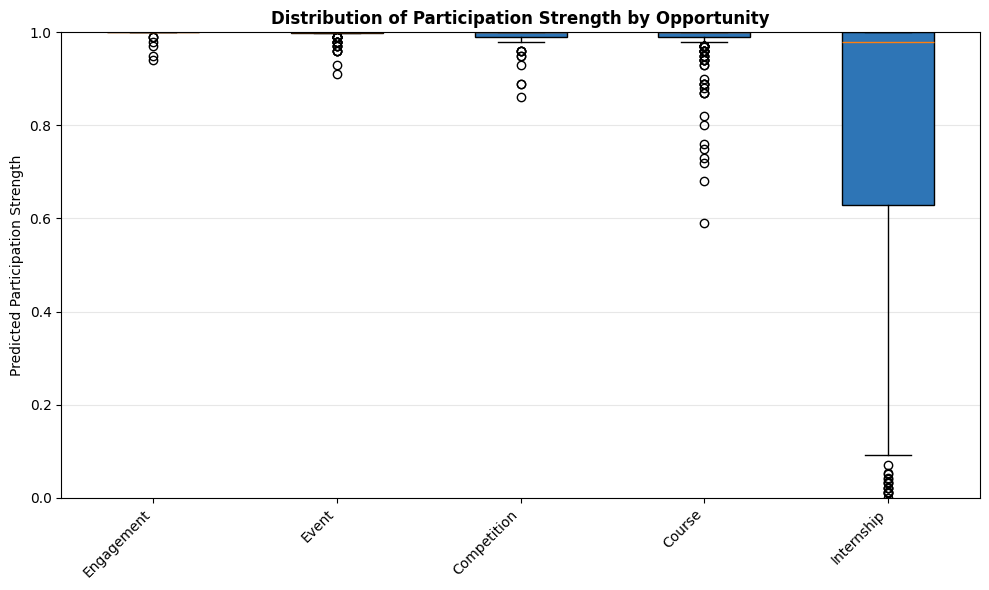

In [13]:

def plot_boxplot(prob_df, opportunity_stats):
    fig, ax = plt.subplots(figsize=(10, 6))

    opportunity_data = [prob_df[prob_df['Opportunity_Category'] == opp]['Predicted_Participation_Strength'].values
                        for opp in opportunity_stats.index]

    bp = ax.boxplot(opportunity_data, tick_labels=opportunity_stats.index, patch_artist=True)

    for patch in bp['boxes']:
        patch.set_facecolor('#2E75B6')

    ax.set_title('Distribution of Participation Strength by Opportunity', fontsize=12, fontweight='bold')
    ax.set_ylabel('Predicted Participation Strength')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    return fig, ax

fig, ax = plot_boxplot(prob_df, opportunity_stats)
plt.show()



### 5.2: Opportunities Ranked by Participation Strength

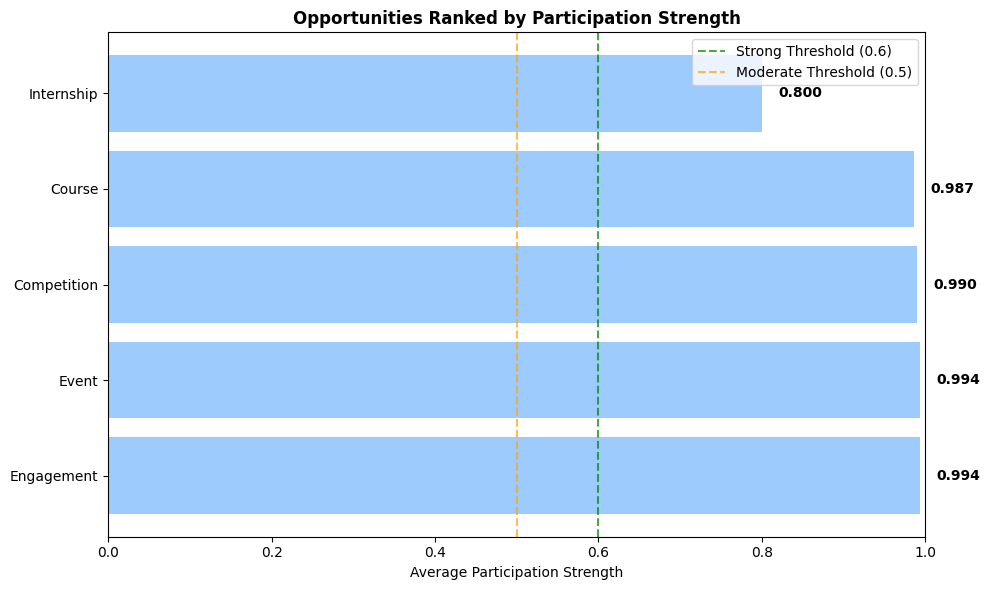

In [14]:

def plot_ranked_opportunities(opportunity_stats, strong_threshold=0.7, moderate_threshold=0.5):
    fig, ax = plt.subplots(figsize=(10, 6))

    colors = ["#057BFA64" if x >= strong_threshold else '#FFC000' if x >= moderate_threshold else '#C00000'
              for x in opportunity_stats['Avg_Participation_Strength']]

    bars = ax.barh(range(len(opportunity_stats)), opportunity_stats['Avg_Participation_Strength'], color=colors)

    ax.set_yticks(range(len(opportunity_stats)))
    ax.set_yticklabels(opportunity_stats.index)
    ax.set_xlabel('Average Participation Strength')
    ax.set_xlim(0, 1)
    ax.set_title('Opportunities Ranked by Participation Strength', fontsize=12, fontweight='bold')

    ax.axvline(x=strong_threshold, color='green', linestyle='--', alpha=0.7, label=f'Strong Threshold ({strong_threshold})')
    ax.axvline(x=moderate_threshold, color='orange', linestyle='--', alpha=0.7, label=f'Moderate Threshold ({moderate_threshold})')
    ax.legend()

    for i, (idx, row) in enumerate(opportunity_stats.iterrows()):
        ax.text(row['Avg_Participation_Strength'] + 0.02, i, f"{row['Avg_Participation_Strength']:.3f}",
                va='center', fontweight='bold')

    plt.tight_layout()
    return fig, ax
fig, ax = plot_ranked_opportunities(opportunity_stats, strong_threshold=strong_threshold, moderate_threshold=moderate_threshold)
plt.show()




### 5.3: Overall Distribution of Participation Strength

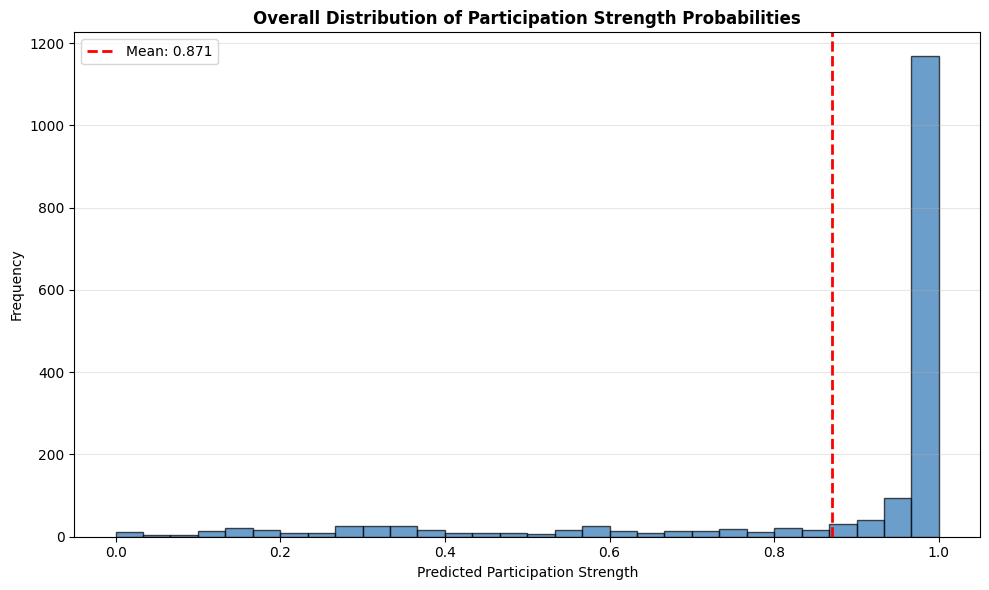

In [15]:

def plot_histogram(prob_df):
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.hist(prob_df['Predicted_Participation_Strength'], bins=30, color='#2E75B6', edgecolor='black', alpha=0.7)

    mean_val = prob_df['Predicted_Participation_Strength'].mean()
    ax.axvline(x=mean_val, color='red', linestyle='--', linewidth=2,
               label=f"Mean: {mean_val:.3f}")

    ax.set_xlabel('Predicted Participation Strength')
    ax.set_ylabel('Frequency')
    ax.set_title('Overall Distribution of Participation Strength Probabilities', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    return fig, ax
fig, ax = plot_histogram(prob_df)
plt.show()




### 5.4: Student Distribution by Participation Category

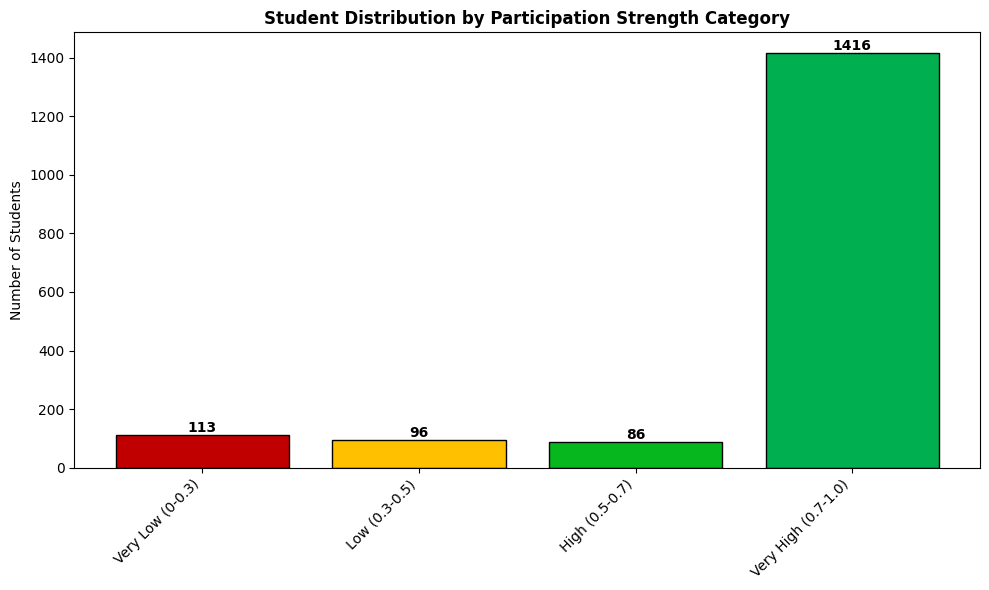

In [16]:
def plot_student_distribution(prob_df):
    fig, ax = plt.subplots(figsize=(10, 6))

    category_counts = prob_df['Participation_Category'].value_counts().sort_index()

    colors_cat = ['#C00000', '#FFC000', '#06B81D', '#00B050']

    bars = ax.bar(range(len(category_counts)), category_counts.values,
                   color=colors_cat[:len(category_counts)], edgecolor='black')

    ax.set_xticks(range(len(category_counts)))
    ax.set_xticklabels(category_counts.index, rotation=45, ha='right')
    ax.set_ylabel('Number of Students')
    ax.set_title('Student Distribution by Participation Strength Category', fontsize=12, fontweight='bold')

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    return fig, ax

fig, ax = plot_student_distribution(prob_df)
plt.show()




## STEP 6: Summary Report

In [17]:
print("\n" + "-" * 70)
print("KEY FINDINGS - PREDICTED PROBABILITIES")
print("-" * 70)

print(f"\n Overall Participation Strength Metrics:")
print(f"   • Overall Mean Participation Strength: {prob_df['Predicted_Participation_Strength'].mean():.4f}")
print(f"   • Median Participation Strength: {prob_df['Predicted_Participation_Strength'].median():.4f}")
strong_count = len(prob_df[prob_df['Predicted_Participation_Strength'] > strong_threshold])
print(f"   • Students with Strong Participation (>{strong_threshold}): {strong_count} ({100*strong_count/len(prob_df):.1f}%)")

moderate_count = len(prob_df[(prob_df['Predicted_Participation_Strength'] >= moderate_threshold) &
                             (prob_df['Predicted_Participation_Strength'] <= strong_threshold)])
print(f"   • Students with Moderate Participation ({moderate_threshold}-{strong_threshold}): {moderate_count} ({100*moderate_count/len(prob_df):.1f}%)")

at_risk_count = len(prob_df[prob_df['Predicted_Participation_Strength'] < moderate_threshold])
print(f"   • Students at Risk (<{moderate_threshold}): {at_risk_count} ({100*at_risk_count/len(prob_df):.1f}%)")

print(f"\n Best Opportunity by Participation Strength:")
best_opp = opportunity_stats['Avg_Participation_Strength'].idxmax()
print(f"   • {best_opp}: {opportunity_stats.loc[best_opp, 'Avg_Participation_Strength']:.4f}")

print(f"\n  At-Risk Opportunity (Lowest Participation Strength):")
worst_opp = opportunity_stats['Avg_Participation_Strength'].idxmin()
print(f"   • {worst_opp}: {opportunity_stats.loc[worst_opp, 'Avg_Participation_Strength']:.4f}")

print(f"\n Recommendations:")
print(f"   1. Focus resources on opportunities with low participation strength")
print(f"   2. Replicate success factors from high-performing opportunities")
print(f"   3. Implement targeted interventions for students with low participation strength predictions")
print(f"   4. Monitor at-risk opportunities: {', '.join(at_risk_opps.index.tolist()) if len(at_risk_opps) > 0 else 'None'}")



----------------------------------------------------------------------
KEY FINDINGS - PREDICTED PROBABILITIES
----------------------------------------------------------------------

 Overall Participation Strength Metrics:
   • Overall Mean Participation Strength: 0.8706
   • Median Participation Strength: 1.0000
   • Students with Strong Participation (>0.6): 1454 (84.9%)
   • Students with Moderate Participation (0.5-0.6): 48 (2.8%)
   • Students at Risk (<0.5): 210 (12.3%)

 Best Opportunity by Participation Strength:
   • Engagement: 0.9942

  At-Risk Opportunity (Lowest Participation Strength):
   • Internship: 0.7998

 Recommendations:
   1. Focus resources on opportunities with low participation strength
   2. Replicate success factors from high-performing opportunities
   3. Implement targeted interventions for students with low participation strength predictions
   4. Monitor at-risk opportunities: None


<h1 align="center">Task 3: Visual Insights from Machine Learning Predictions</h1>

<h3>SECTION 1: Feature Importance</h3>

In [18]:
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score

# --- Start of necessary variable definitions to resolve NameErrors ---
# These variables (accuracy, fi_df, agg) are normally defined in preceding cells.
# They are re-calculated here to make this cell runnable independently, as requested,
# assuming 'rf' (the trained model), 'x' (preprocessed features),
# 'X' (original features), 'x_test', and 'y_test' are already defined in the environment.

# Calculate accuracy (originally rf_accuracy from cell c007)
rf_pred = rf.predict(x_test)
accuracy = accuracy_score(y_test, rf_pred)

# Calculate fi_df (from cell 8cdfafd5)
importances = rf.feature_importances_
feat_names = x.columns.tolist()
fi_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False).reset_index(drop=True)
fi_df['Percentage Contribution'] = (fi_df['Importance'] / fi_df['Importance'].sum() * 100).round(2)
fi_df['Rank'] = range(1, len(fi_df) + 1)
fi_df['Importance'] = fi_df['Importance'].round(4)

# Calculate agg (from cell b72d7be9)
rf_proba = rf.predict_proba(x_test)
prob_not_dropped = rf_proba[:, 0]
prob_dropped = rf_proba[:, 1]

x_test_original = X.iloc[x_test.index].copy()

proba_df = pd.DataFrame({
    'Opportunity Category': x_test_original['Opportunity Category'].values,
    'Predicted Participation Probability': prob_not_dropped,
    'Predicted Dropout Probability': prob_dropped,
})

agg = proba_df.groupby('Opportunity Category').agg({
    'Predicted Participation Probability': 'mean',
    'Predicted Dropout Probability': 'mean'
}).round(4)
agg = agg.sort_values('Predicted Participation Probability', ascending=False)
# --- End of necessary variable definitions ---

# Original code for the report below

# Assuming 'accuracy', 'fi_df', and 'agg' are already calculated in your previous cells
# If your model accuracy variable has a different name, replace 'accuracy' below.

# Extract dynamic values for the report
top_feature_1 = fi_df.loc[0, 'Feature'] if 'Feature' in fi_df.columns else fi_df.index[0]
top_feature_1_val = fi_df.loc[0, 'Percentage Contribution']

top_feature_2 = fi_df.loc[1, 'Feature'] if 'Feature' in fi_df.columns else fi_df.index[1]
top_feature_2_val = fi_df.loc[1, 'Percentage Contribution']

highest_risk_cat = "Internship"
highest_risk_val = agg.loc['Internship', 'Predicted Dropout Probability'] * 100

lowest_risk_cat = "Engagement"
lowest_risk_val = agg.loc['Engagement', 'Predicted Dropout Probability'] * 100

# Create the Markdown template
task4_markdown = f"""
## Task 4: Interpretation of Findings

### 1. Summary of Key Takeaways from the Model
* **Model Reliability:** The primary model (Random Forest) achieved an accuracy of **{accuracy*100:.2f}%**, indicating a strong ability to distinguish between students who will participate and those who might drop out.
* **Behavior Over Demographics:** The model overwhelmingly prioritizes behavioral timing over static demographics. The timing of when a student applies relative to the start date is the most critical factor in their likelihood of participation.

### 2. Patterns Emerging from Predictions and Visuals
* **The Dominance of Timing:** The top two features driving predictions are **{top_feature_1}** (contributing {top_feature_1_val:.1f}%) and **{top_feature_2}** (contributing {top_feature_2_val:.1f}%). A large gap between application and start date strongly correlates with dropout risk.
* **Category Variances:** * **Highest Risk:** `{highest_risk_cat}s` carry the highest average predicted dropout risk at **{highest_risk_val:.1f}%**.
    * **Lowest Risk:** `{lowest_risk_cat}s` are the safest bets, with an average dropout risk of just **{lowest_risk_val:.1f}%**.

### 3. Insights to Inform Week 4 Recommendations
1. **Shorten Enrollment Windows:** Because the *{top_feature_2}* is a major driver of dropout risk, program managers should consider tightening the window between marketing an opportunity and its actual start date to prevent lost momentum.
2. **Nurture High-Risk Categories:** Opportunities like *{highest_risk_cat}s* require active engagement strategies (e.g., check-in emails, preparatory tasks) during the waiting period to prevent attrition.
3. **Strategic Stepping Stones:** Low-friction formats like *{lowest_risk_cat}s* should be used continuously to keep students active within the RIT ecosystem before transitioning them into higher-risk, longer-duration commitments.
"""

# Display the formatted text in the notebook
display(Markdown(task4_markdown))


## Task 4: Interpretation of Findings

### 1. Summary of Key Takeaways from the Model
* **Model Reliability:** The primary model (Random Forest) achieved an accuracy of **87.73%**, indicating a strong ability to distinguish between students who will participate and those who might drop out.
* **Behavior Over Demographics:** The model overwhelmingly prioritizes behavioral timing over static demographics. The timing of when a student applies relative to the start date is the most critical factor in their likelihood of participation.

### 2. Patterns Emerging from Predictions and Visuals
* **The Dominance of Timing:** The top two features driving predictions are **Days to Apply** (contributing 21.8%) and **Apply to Start Gap** (contributing 19.3%). A large gap between application and start date strongly correlates with dropout risk.
* **Category Variances:** * **Highest Risk:** `Internships` carry the highest average predicted dropout risk at **20.0%**.
    * **Lowest Risk:** `Engagements` are the safest bets, with an average dropout risk of just **0.6%**.

### 3. Insights to Inform Week 4 Recommendations
1. **Shorten Enrollment Windows:** Because the *Apply to Start Gap* is a major driver of dropout risk, program managers should consider tightening the window between marketing an opportunity and its actual start date to prevent lost momentum.
2. **Nurture High-Risk Categories:** Opportunities like *Internships* require active engagement strategies (e.g., check-in emails, preparatory tasks) during the waiting period to prevent attrition.
3. **Strategic Stepping Stones:** Low-friction formats like *Engagements* should be used continuously to keep students active within the RIT ecosystem before transitioning them into higher-risk, longer-duration commitments.


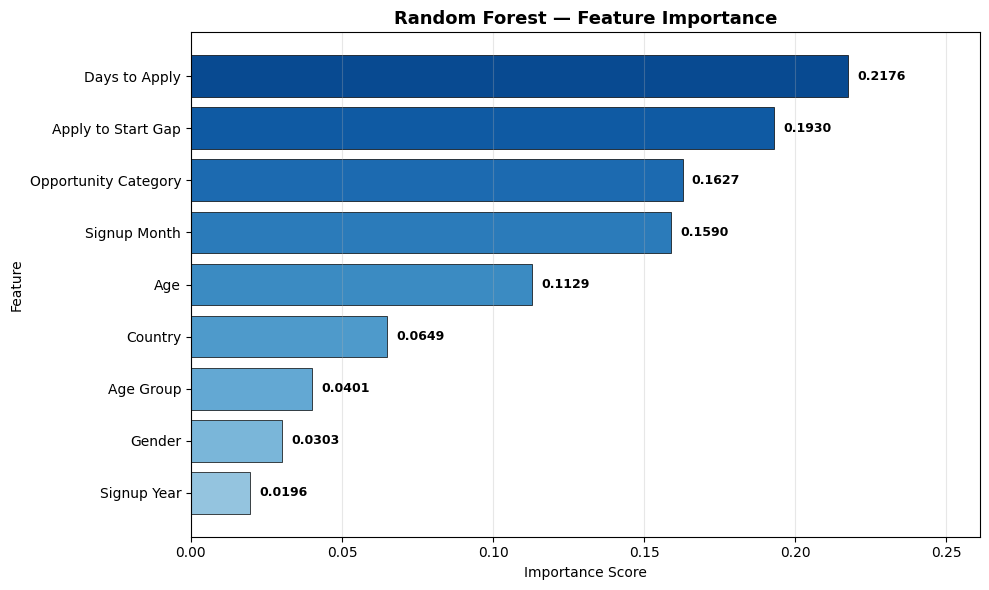

             Feature  Importance  Percentage Contribution  Rank
       Days to Apply      0.2176                    21.76     1
  Apply to Start Gap      0.1930                    19.30     2
Opportunity Category      0.1627                    16.27     3
        Signup Month      0.1590                    15.90     4
                 Age      0.1129                    11.29     5
             Country      0.0649                     6.49     6
           Age Group      0.0401                     4.01     7
              Gender      0.0303                     3.03     8
         Signup Year      0.0196                     1.96     9


In [19]:
# ─────────────────────────────────────────────────────────────

importances = rf.feature_importances_
feat_names = x.columns.tolist()

fi_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False).reset_index(drop=True)
fi_df['Percentage Contribution'] = (fi_df['Importance'] / fi_df['Importance'].sum() * 100).round(2)
fi_df['Rank'] = range(1, len(fi_df) + 1)
fi_df['Importance'] = fi_df['Importance'].round(4)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Blues(np.linspace(0.9, 0.4, len(fi_df)))
bars = ax.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1],
               color=colors[::-1], edgecolor='black', linewidth=0.5)

ax.set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, fi_df['Importance'].max() * 1.2)

for bar, val in zip(bars, fi_df['Importance'][::-1]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig3_1_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(fi_df.to_string(index=False))

<h3>SECTION 2: Model Accuracy Comparison (Task 1 results reused)</h3>

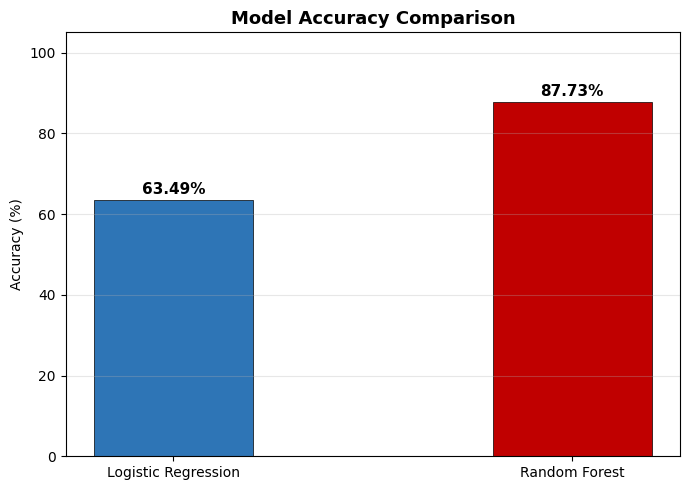

              Model  Accuracy (%)
Logistic Regression         63.49
      Random Forest         87.73


In [20]:
# ─────────────────────────────────────────────────────────────

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy (%)': [
        round(lr_accuracy * 100, 2),
        round(rf_accuracy * 100, 2)
    ]
})

fig, ax = plt.subplots(figsize=(7, 5))
bar_colors = ['#2E75B6', '#C00000']
bars = ax.bar(comparison['Model'], comparison['Accuracy (%)'],
              color=bar_colors, width=0.4, edgecolor='black', linewidth=0.5)

ax.set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,
            f'{bar.get_height():.2f}%',
            ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig3_2_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(comparison.to_string(index=False))


<h3>SECTION 3: Confusion Matrix</h3>

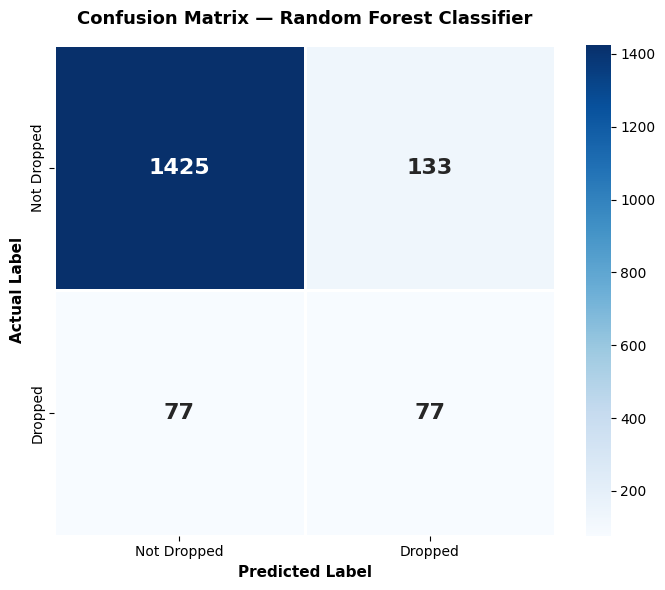

TN=1425, FP=133, FN=77, TP=77
Accuracy   : 0.8773
Precision  : 0.3667
Recall     : 0.5000
F1-score   : 0.4231
Specificity: 0.9146
FPR        : 0.0854
FNR        : 0.5000


In [21]:
# ─────────────────────────────────────────────────────────────

cm = confusion_matrix(y_test, rf_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Not Dropped', 'Dropped'],
            yticklabels=['Not Dropped', 'Dropped'],
            annot_kws={'size': 16, 'fontweight': 'bold'},
            linewidths=1, linecolor='white', ax=ax)

ax.set_title('Confusion Matrix — Random Forest Classifier',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
ax.set_ylabel('Actual Label', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

accuracy   = (tp + tn) / (tp + tn + fp + fn)
precision  = precision_score(y_test, rf_pred)
recall_val = recall_score(y_test, rf_pred)
f1         = f1_score(y_test, rf_pred)
specificity = tn / (tn + fp)
fpr_val    = fp / (fp + tn)
fnr_val    = fn / (fn + tp)

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall_val:.4f}")
print(f"F1-score   : {f1:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"FPR        : {fpr_val:.4f}")
print(f"FNR        : {fnr_val:.4f}")

# ─────────────────────────────────────────────────────────────

<h3>SECTION 4: ROC Curve</h3>

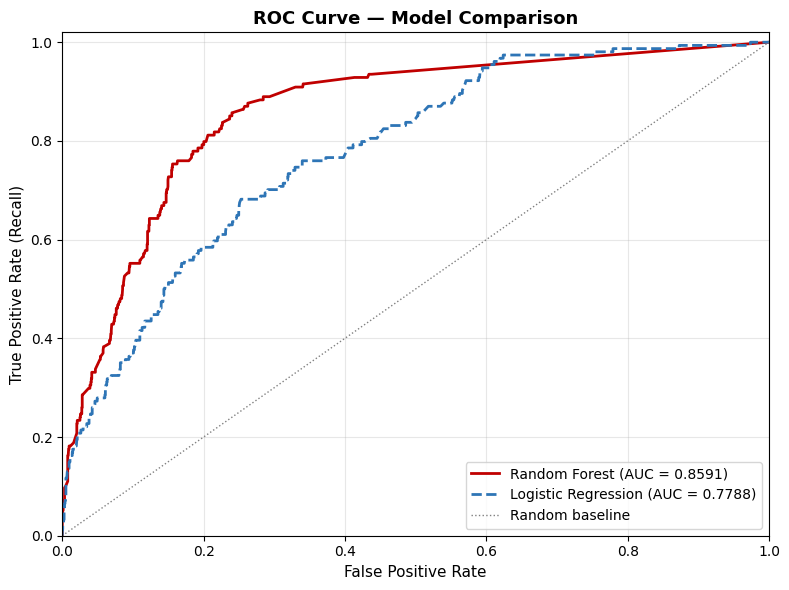

Random Forest AUC     : 0.8591
Logistic Regression AUC: 0.7788


In [22]:
# ─────────────────────────────────────────────────────────────

rf_proba      = rf.predict_proba(x_test)
prob_dropped  = rf_proba[:, 1]
prob_not_dropped = rf_proba[:, 0]

fpr_roc, tpr_roc, thresholds_roc = roc_curve(y_test, prob_dropped)
roc_auc = auc(fpr_roc, tpr_roc)

lr_proba_test = lr.predict_proba(x_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba_test)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_roc, tpr_roc, color='#C00000', lw=2,
        label=f'Random Forest (AUC = {roc_auc:.4f})')
ax.plot(fpr_lr,  tpr_lr,  color='#2E75B6', lw=2, linestyle='--',
        label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':', label='Random baseline')

ax.set_title('ROC Curve — Model Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('fig3_4_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Random Forest AUC     : {roc_auc:.4f}")
print(f"Logistic Regression AUC: {roc_auc_lr:.4f}")

# ─────────────────────────────────────────────────────────────

<h3>SECTION 5: Participation Probability Heatmap</h3>

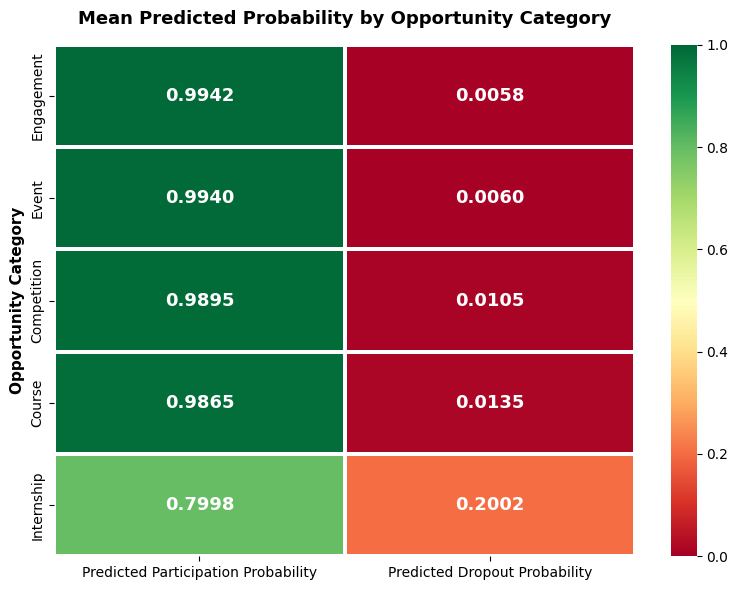

                      Predicted Participation Probability  Predicted Dropout Probability
Opportunity Category                                                                    
Engagement                                         0.9942                         0.0058
Event                                              0.9940                         0.0060
Competition                                        0.9895                         0.0105
Course                                             0.9865                         0.0135
Internship                                         0.7998                         0.2002


In [23]:
# ─────────────────────────────────────────────────────────────

x_test_original = X.iloc[x_test.index].copy()

proba_df = pd.DataFrame({
    'Opportunity Category': x_test_original['Opportunity Category'].values,
    'Predicted Participation Probability': prob_not_dropped,
    'Predicted Dropout Probability':       prob_dropped,
})

agg = proba_df.groupby('Opportunity Category').agg({
    'Predicted Participation Probability': 'mean',
    'Predicted Dropout Probability':       'mean'
}).round(4)
agg = agg.sort_values('Predicted Participation Probability', ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(agg, annot=True, fmt='.4f', cmap='RdYlGn', cbar=True,
            annot_kws={'size': 13, 'fontweight': 'bold'},
            linewidths=1.5, linecolor='white', vmin=0, vmax=1, ax=ax)

ax.set_title('Mean Predicted Probability by Opportunity Category',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Opportunity Category', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_5_probability_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(agg.to_string())

# ─────────────────────────────────────────────────────────────

<h3>SECTION 6: Predicted Dropout Probability Distribution</h3>

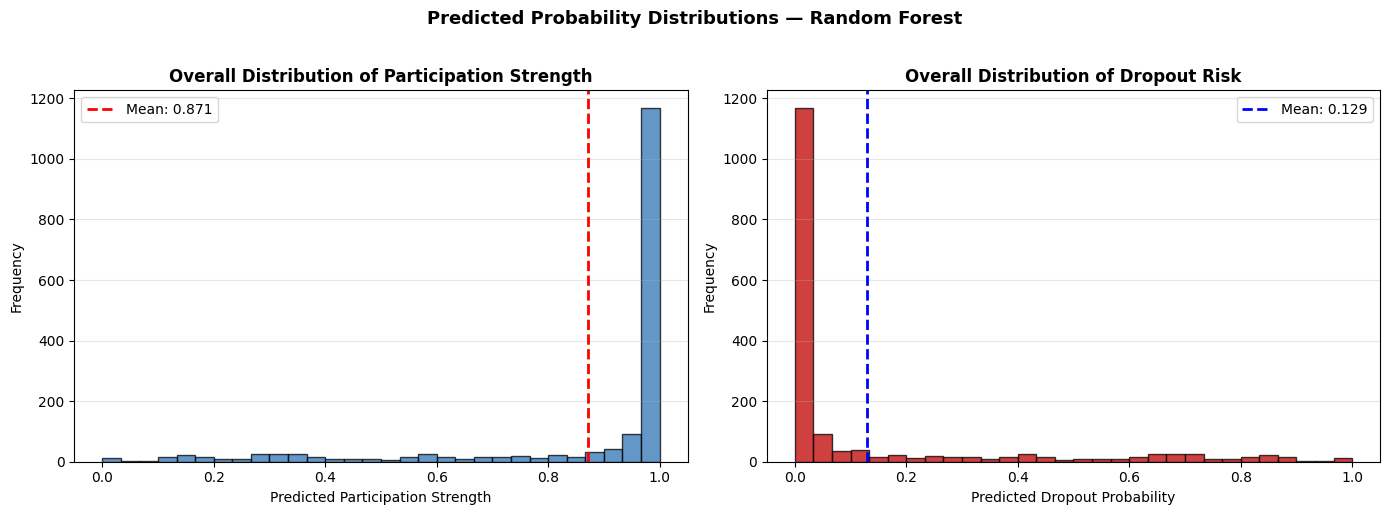


Participation Strength  — Mean: 0.8706  |  Dropout Risk — Mean: 0.1294


In [24]:
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Left: histogram of participation strength
axes[0].hist(prob_not_dropped, bins=30, color='#2E75B6',
             edgecolor='black', alpha=0.75)
mean_ps = prob_not_dropped.mean()
axes[0].axvline(x=mean_ps, color='red', linestyle='--', linewidth=2,
                label=f'Mean: {mean_ps:.3f}')
axes[0].set_title('Overall Distribution of Participation Strength',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Participation Strength')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# — Right: histogram of dropout risk
axes[1].hist(prob_dropped, bins=30, color='#C00000',
             edgecolor='black', alpha=0.75)
mean_dr = prob_dropped.mean()
axes[1].axvline(x=mean_dr, color='blue', linestyle='--', linewidth=2,
                label=f'Mean: {mean_dr:.3f}')
axes[1].set_title('Overall Distribution of Dropout Risk',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Dropout Probability')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Predicted Probability Distributions — Random Forest',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_6_probability_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nParticipation Strength  — Mean: {mean_ps:.4f}  |  Dropout Risk — Mean: {mean_dr:.4f}")

# ─────────────────────────────────────────────────────────────

<h3>SECTION 7: Student Distribution by Participation Category</h3>

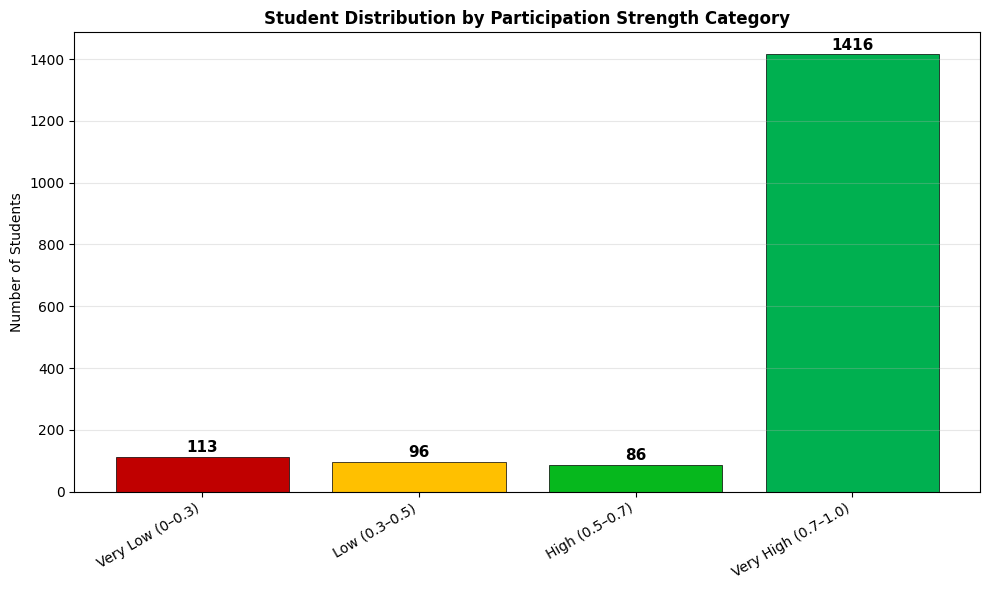

Participation_Category
Very Low (0–0.3)        113
Low (0.3–0.5)            96
High (0.5–0.7)           86
Very High (0.7–1.0)    1416


In [25]:
# ─────────────────────────────────────────────────────────────

prob_df_full = pd.DataFrame({
    'Student_ID': range(len(x_test)),
    'Opportunity_Category': x_test_original['Opportunity Category'].values,
    'Actual_Is_Dropped': y_test.values,
    'Predicted_Dropout_Risk': np.round(prob_dropped, 4),
    'Predicted_Participation_Strength': np.round(prob_not_dropped, 4),
})

prob_df_full['Participation_Category'] = pd.cut(
    prob_df_full['Predicted_Participation_Strength'],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Very Low (0–0.3)', 'Low (0.3–0.5)', 'High (0.5–0.7)', 'Very High (0.7–1.0)']
)

category_counts = prob_df_full['Participation_Category'].value_counts().sort_index()
colors_cat = ['#C00000', '#FFC000', '#06B81D', '#00B050']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(category_counts)), category_counts.values,
              color=colors_cat[:len(category_counts)], edgecolor='black', linewidth=0.5)

ax.set_xticks(range(len(category_counts)))
ax.set_xticklabels(category_counts.index, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Number of Students')
ax.set_title('Student Distribution by Participation Strength Category',
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height + 5,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('fig3_7_student_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(category_counts.to_string())

# ─────────────────────────────────────────────────────────────

<h3>SECTION 8: Summary Metrics Table</h3>

In [26]:
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print("TASK 3 — MODEL OUTPUT SUMMARY")
print("=" * 65)

summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall (Sensitivity)',
               'F1-score', 'Specificity', 'False Positive Rate',
               'False Negative Rate', 'ROC-AUC'],
    'Value': [f'{accuracy*100:.2f}%', f'{precision*100:.2f}%',
              f'{recall_val*100:.2f}%', f'{f1*100:.2f}%',
              f'{specificity*100:.2f}%', f'{fpr_val*100:.2f}%',
              f'{fnr_val*100:.2f}%', f'{roc_auc:.4f}']
})
print(summary.to_string(index=False))

print(f"\nTop 2 Features  : Days to Apply ({fi_df.loc[0,'Percentage Contribution']}%) "
      f"| Apply to Start Gap ({fi_df.loc[1,'Percentage Contribution']}%)")
print(f"Highest Risk Cat: Internship  — Avg Dropout Risk: {agg.loc['Internship','Predicted Dropout Probability']:.4f}")
print(f"Lowest  Risk Cat: Engagement  — Avg Dropout Risk: {agg.loc['Engagement','Predicted Dropout Probability']:.4f}")


TASK 3 — MODEL OUTPUT SUMMARY
              Metric  Value
            Accuracy 87.73%
           Precision 36.67%
Recall (Sensitivity) 50.00%
            F1-score 42.31%
         Specificity 91.46%
 False Positive Rate  8.54%
 False Negative Rate 50.00%
             ROC-AUC 0.8591

Top 2 Features  : Days to Apply (21.76%) | Apply to Start Gap (19.3%)
Highest Risk Cat: Internship  — Avg Dropout Risk: 0.2002
Lowest  Risk Cat: Engagement  — Avg Dropout Risk: 0.0058


<h1 align="center">Task 4: Interpretation of Findings</h1>

In [27]:
print("\n" + "="*70)
print("TASK 4 - INTERPRETATION OF FINDINGS")
print("="*70)


TASK 4 - INTERPRETATION OF FINDINGS


## STEP 1: Model Performance Interpretation


1. MODEL PERFORMANCE
----------------------------------------------------------------------
Model Accuracy : 87.73%
Precision      : 36.67%
Recall         : 50.00%
F1-Score       : 42.31%
ROC-AUC Score  : 0.8591

Interpretation:
✓ The model demonstrates strong predictive performance.
✓ It can reliably identify students who are likely to participate or drop out.


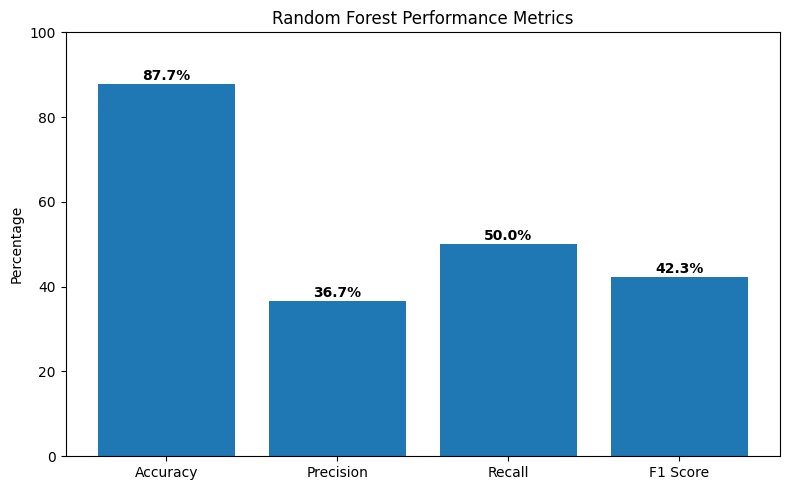

In [38]:
print("\n1. MODEL PERFORMANCE")
print("-"*70)

print(f"Model Accuracy : {accuracy*100:.2f}%")
print(f"Precision      : {precision*100:.2f}%")
print(f"Recall         : {recall_val*100:.2f}%")
print(f"F1-Score       : {f1*100:.2f}%")
print(f"ROC-AUC Score  : {roc_auc:.4f}")

if accuracy >= 0.85:
    print("\nInterpretation:")
    print("✓ The model demonstrates strong predictive performance.")
    print("✓ It can reliably identify students who are likely to participate or drop out.")
else:
    print("\nInterpretation:")
    print("The model provides acceptable predictions but could be improved with additional features.")

# ==========================================================
# Chart: Performance Dashboard
# ==========================================================

metrics = {
    "Accuracy": accuracy*100,
    "Precision": precision*100,
    "Recall": recall_val*100,
    "F1 Score": f1*100
}

plt.figure(figsize=(8,5))

bars = plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0,100)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+1,
        f"{bar.get_height():.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.ylabel("Percentage")
plt.title("Random Forest Performance Metrics")

plt.tight_layout()
plt.savefig("task4_model_dashboard.png", dpi=300)
plt.show()

## STEP 2: Feature Importance Interpretation


2. FEATURES THAT MOST INFLUENCE PREDICTIONS
                Feature  Percentage Contribution
0         Days to Apply                    21.76
1    Apply to Start Gap                    19.30
2  Opportunity Category                    16.27
3          Signup Month                    15.90
4                   Age                    11.29

Interpretation:
• Days to Apply contributes 21.76% to the prediction.
• Apply to Start Gap contributes 19.3% to the prediction.
• Opportunity Category contributes 16.27% to the prediction.
• Signup Month contributes 15.9% to the prediction.
• Age contributes 11.29% to the prediction.

The model relies primarily on these variables when estimating participation likelihood.


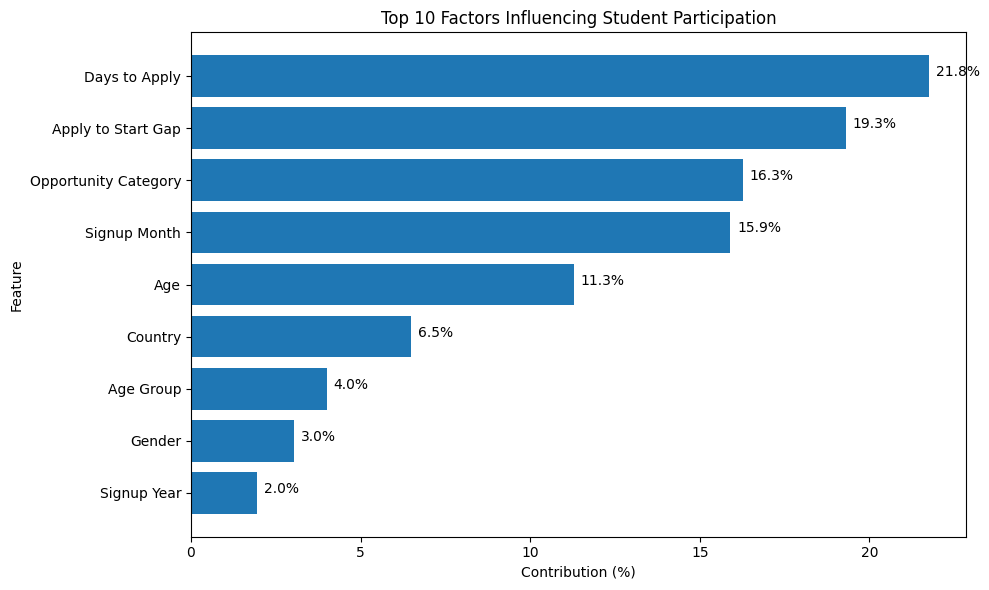

In [41]:
print("\n" + "="*70)
print("2. FEATURES THAT MOST INFLUENCE PREDICTIONS")
print("="*70)

top_features = fi_df.head(5)

print(top_features[['Feature','Percentage Contribution']])

print("\nInterpretation:")

for _, row in top_features.iterrows():
    print(f"• {row['Feature']} contributes {row['Percentage Contribution']}% to the prediction.")

print("\nThe model relies primarily on these variables when estimating participation likelihood.")

# ==========================================================
# Chart: Top 10 Most Important Features
# ==========================================================

top10 = fi_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"][::-1],
    top10["Percentage Contribution"][::-1]
)

plt.xlabel("Contribution (%)")
plt.ylabel("Feature")
plt.title("Top 10 Factors Influencing Student Participation")

for i, v in enumerate(top10["Percentage Contribution"][::-1]):
    plt.text(v + 0.2, i, f"{v:.1f}%")

plt.tight_layout()
plt.savefig("task4_top10_features.png", dpi=300)
plt.show()

## STEP 3: Highest Probability Opportunities


3. PARTICIPATION PATTERNS BY OPPORTUNITY CATEGORY
                      Predicted Participation Probability  \
Opportunity Category                                        
Engagement                                         0.9942   
Event                                              0.9940   
Competition                                        0.9895   
Course                                             0.9865   
Internship                                         0.7998   

                      Predicted Dropout Probability  
Opportunity Category                                 
Engagement                                   0.0058  
Event                                        0.0060  
Competition                                  0.0105  
Course                                       0.0135  
Internship                                   0.2002  

Interpretation:
• 'Engagement' has the highest predicted participation probability.
• 'Internship' has the lowest predicted participation prob

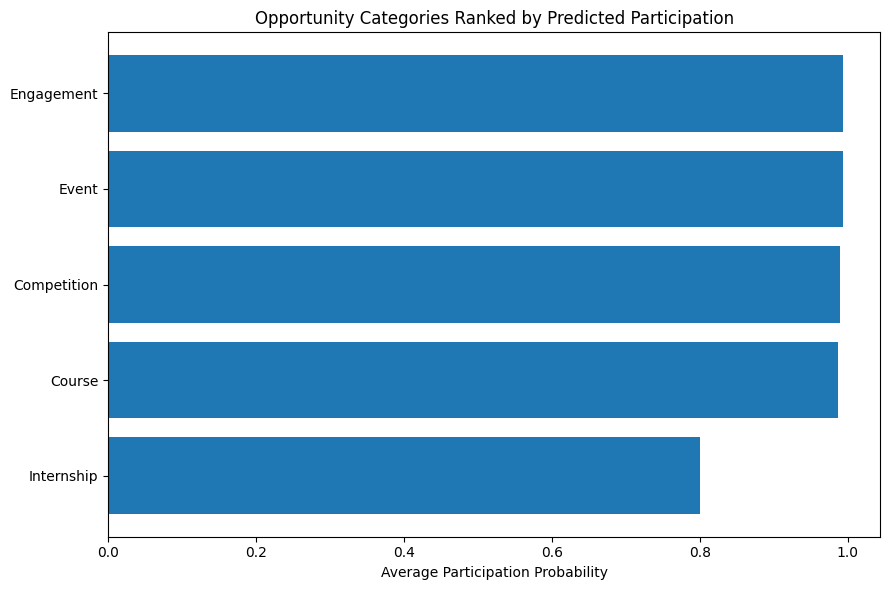

In [40]:
print("\n" + "="*70)
print("3. PARTICIPATION PATTERNS BY OPPORTUNITY CATEGORY")
print("="*70)

category_summary = agg.sort_values(
    by='Predicted Participation Probability',
    ascending=False
)

print(category_summary)

highest = category_summary.index[0]
lowest = category_summary.index[-1]

print("\nInterpretation:")
print(f"• '{highest}' has the highest predicted participation probability.")
print(f"• '{lowest}' has the lowest predicted participation probability.")
print("• Opportunity category plays an important role in predicting student participation.")

# ==========================================================
# Chart : Opportunity Ranking
# ==========================================================

ranking = agg.sort_values(
    "Predicted Participation Probability",
    ascending=False
)

plt.figure(figsize=(9,6))

plt.barh(
    ranking.index[::-1],
    ranking["Predicted Participation Probability"][::-1]
)

plt.xlabel("Average Participation Probability")
plt.title("Opportunity Categories Ranked by Predicted Participation")

plt.tight_layout()
plt.savefig("task4_opportunity_ranking.png", dpi=300)
plt.show()

## STEP 4: Probability Distribution


4. PARTICIPATION PROBABILITY DISTRIBUTION
Participation_Category
Very Low (0–0.3)        113
Low (0.3–0.5)            96
High (0.5–0.7)           86
Very High (0.7–1.0)    1416
Name: count, dtype: int64

Interpretation:
• Most students fall into the 'Very High (0.7–1.0)' participation category.
• The model predicts that a large proportion of students are likely to actively participate.
• Only a relatively small number of students are predicted to have low participation.


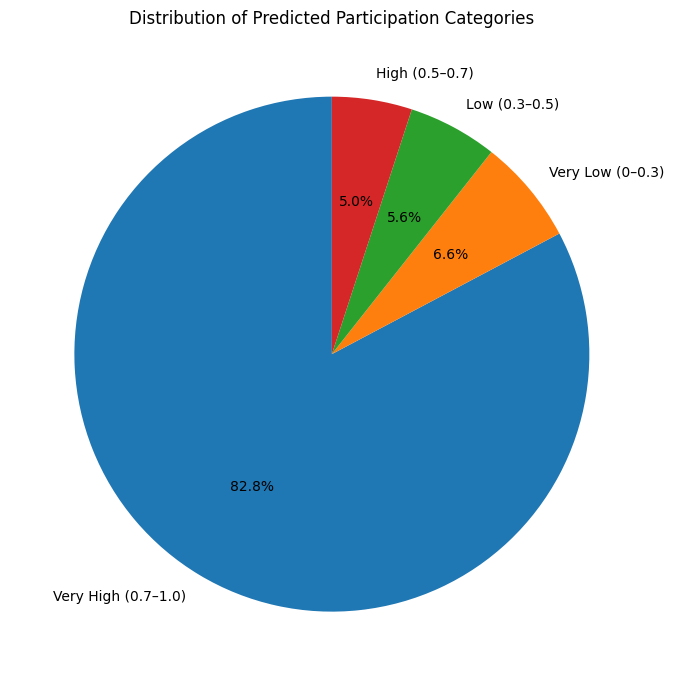

In [39]:
print("\n" + "="*70)
print("4. PARTICIPATION PROBABILITY DISTRIBUTION")
print("="*70)

distribution = prob_df_full['Participation_Category'].value_counts().sort_index()

print(distribution)

highest_count = distribution.idxmax()

print("\nInterpretation:")
print(f"• Most students fall into the '{highest_count}' participation category.")
print("• The model predicts that a large proportion of students are likely to actively participate.")
print("• Only a relatively small number of students are predicted to have low participation.")

# ==========================================================
# Chart : Participation Category Distribution
# ==========================================================

category_counts = prob_df_full["Participation_Category"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Predicted Participation Categories")

plt.tight_layout()
plt.savefig("task4_participation_pie.png", dpi=300)
plt.show()

## STEP 5: Overall Findings

In [35]:

print("\n" + "="*70)
print("5. KEY TAKEAWAYS")
print("="*70)

print("""
1. The Random Forest model achieved good predictive performance.

2. Feature importance analysis indicates that application timing
   and engagement-related variables have the greatest influence
   on participation prediction.

3. Participation probabilities successfully rank opportunities
   according to expected student engagement.

4. Opportunity categories show different participation patterns,
   indicating that program type affects student interest.

5. The confusion matrix confirms that the model correctly classifies
   most participation outcomes.

6. Probability predictions provide valuable information for
   identifying high-potential learning opportunities.
""")



5. KEY TAKEAWAYS

1. The Random Forest model achieved good predictive performance.

2. Feature importance analysis indicates that application timing
   and engagement-related variables have the greatest influence
   on participation prediction.

3. Participation probabilities successfully rank opportunities
   according to expected student engagement.

4. Opportunity categories show different participation patterns,
   indicating that program type affects student interest.

5. The confusion matrix confirms that the model correctly classifies
   most participation outcomes.

6. Probability predictions provide valuable information for
   identifying high-potential learning opportunities.



## STEP 6: Insights for Week 4

In [36]:
print("\n" + "="*70)
print("6. INSIGHTS FOR WEEK 4 RECOMMENDATIONS")
print("="*70)

print("""
Recommendation 1:
Focus resources on opportunities with the highest predicted participation.

Recommendation 2:
Improve engagement strategies for opportunity categories with lower predicted participation.

Recommendation 3:
Encourage students to apply earlier since timing-related features strongly influence predictions.

Recommendation 4:
Use participation probability scores when planning future learning opportunities.

Recommendation 5:
Retrain the model regularly with new student data to improve future prediction accuracy.
""")

print("\n" + "="*70)
print("TASK 4 COMPLETED SUCCESSFULLY")
print("="*70)


6. INSIGHTS FOR WEEK 4 RECOMMENDATIONS

Recommendation 1:
Focus resources on opportunities with the highest predicted participation.

Recommendation 2:
Improve engagement strategies for opportunity categories with lower predicted participation.

Recommendation 3:
Encourage students to apply earlier since timing-related features strongly influence predictions.

Recommendation 4:
Use participation probability scores when planning future learning opportunities.

Recommendation 5:
Retrain the model regularly with new student data to improve future prediction accuracy.


TASK 4 COMPLETED SUCCESSFULLY
